In [1]:
# SETUP CELL
import os
os.chdir('/home/sundhar/projects/data-science/sales-forecasting-project')
print(f"Working directory: {os.getcwd()}")

# Verify data exists
if os.path.exists('data/cleaned_sales_data.csv'):
    print("✓ Cleaned data found!")
else:
    print("⚠ Cleaned data not found. Run Notebook 1 first.")

Working directory: /home/sundhar/projects/data-science/sales-forecasting-project
✓ Cleaned data found!


In [2]:
# CELL 1: Setup - Run this first
import os
os.chdir('/home/sundhar/projects/data-science/sales-forecasting-project')
print(f"Working directory: {os.getcwd()}")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set styling
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ All imports successful")

Working directory: /home/sundhar/projects/data-science/sales-forecasting-project
✓ All imports successful


In [3]:
# CELL 2: Load and Explore Data
# Load the dataset
df = pd.read_csv('data/retail_sales_data.csv', parse_dates=['Date'])
df.set_index('Date', inplace=True)

# Sort index chronologically
df.sort_index(inplace=True)

print("="*80)
print("DATASET OVERVIEW")
print("="*80)
print(f"Dataset Shape: {df.shape}")
print(f"Date Range: {df.index.min()} to {df.index.max()}")
print(f"Total Records: {len(df):,}")
print(f"Total Sales: ${df['Sales_Amount'].sum():,.2f}")

print("\n" + "="*80)
print("FIRST 5 ROWS")
print("="*80)
print(df.head())

DATASET OVERVIEW
Dataset Shape: (21900, 12)
Date Range: 2021-01-01 00:00:00 to 2023-12-31 00:00:00
Total Records: 21,900
Total Sales: $11,956,693.17

FIRST 5 ROWS
            Year  Month  Day  Weekday Product_Category Region  Sales_Amount  \
Date                                                                          
2021-01-01  2021      1    1        4      Electronics  North        451.63   
2021-01-01  2021      1    1        4      Electronics  South        696.24   
2021-01-01  2021      1    1        4      Electronics   East        494.91   
2021-01-01  2021      1    1        4      Electronics   West        494.91   
2021-01-01  2021      1    1        4         Clothing  North        428.15   

            Units_Sold  Promotion_Active  Holiday  Weekend  Month_End  
Date                                                                   
2021-01-01           0             False     True    False      False  
2021-01-01           1              True     True    False      Fal

In [4]:
# CELL 3: Data Quality Assessment
print("="*80)
print("DATA QUALITY ASSESSMENT")
print("="*80)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

print("\nData Types:")
print(df.dtypes.value_counts())

print("\nBasic Statistics:")
print(df[['Sales_Amount', 'Units_Sold']].describe().round(2))

DATA QUALITY ASSESSMENT

Missing Values:
Year                0
Month               0
Day                 0
Weekday             0
Product_Category    0
Region              0
Sales_Amount        0
Units_Sold          0
Promotion_Active    0
Holiday             0
Weekend             0
Month_End           0
dtype: int64

Duplicate Rows: 0

Data Types:
int64      5
bool       4
object     2
float64    1
Name: count, dtype: int64

Basic Statistics:
       Sales_Amount  Units_Sold
count      21900.00    21900.00
mean         545.97       10.39
std          261.04       10.03
min          204.37        0.00
25%          392.86        4.00
50%          493.56        8.00
75%          633.07       14.00
max         5408.78      153.00


Outliers in Sales_Amount: 873 records (3.99%)
Normal range: $32.56 - $993.38

✓ Created 'Sales_Amount_Capped' column


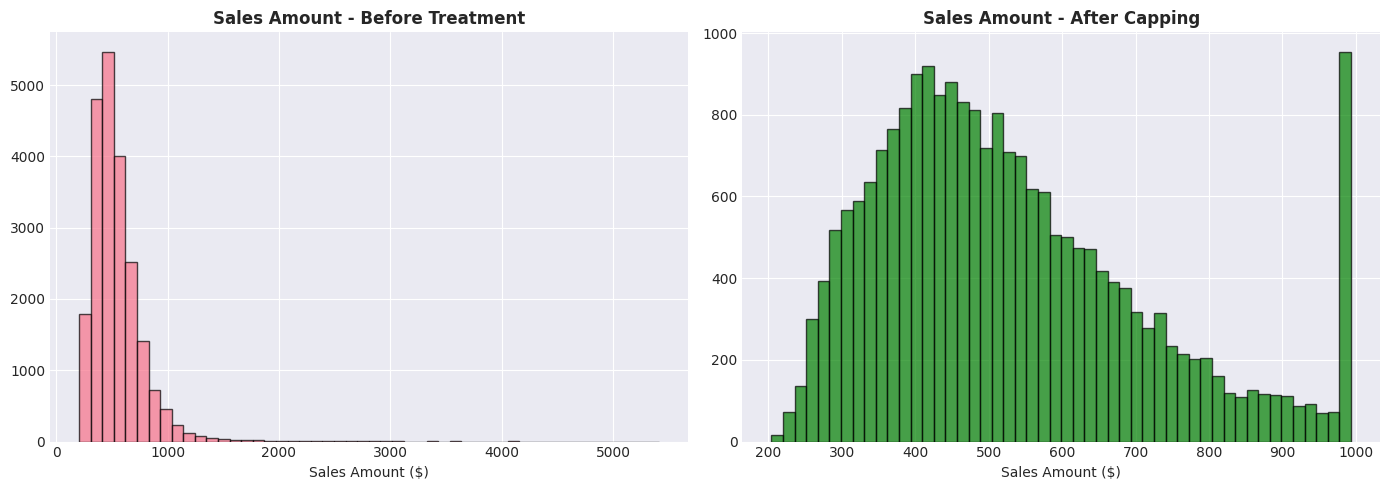

In [5]:
# CELL 4: Outlier Detection and Treatment
def detect_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

# Check outliers
sales_outliers, sales_lower, sales_upper = detect_outliers(df, 'Sales_Amount')
print(f"Outliers in Sales_Amount: {len(sales_outliers)} records ({len(sales_outliers)/len(df)*100:.2f}%)")
print(f"Normal range: ${sales_lower:,.2f} - ${sales_upper:,.2f}")

# Create capped version
df['Sales_Amount_Capped'] = df['Sales_Amount'].clip(lower=sales_lower, upper=sales_upper)

print("\n✓ Created 'Sales_Amount_Capped' column")

# Visualize before and after
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['Sales_Amount'], bins=50, alpha=0.7, edgecolor='black')
axes[0].set_title('Sales Amount - Before Treatment', fontweight='bold')
axes[0].set_xlabel('Sales Amount ($)')

axes[1].hist(df['Sales_Amount_Capped'], bins=50, alpha=0.7, edgecolor='black', color='green')
axes[1].set_title('Sales Amount - After Capping', fontweight='bold')
axes[1].set_xlabel('Sales Amount ($)')

plt.tight_layout()
plt.show()

In [6]:
# CELL 5: Create Time-Based Features
print("="*80)
print("CREATING TIME-BASED FEATURES")
print("="*80)

# Extract comprehensive time features
df['Year'] = df.index.year
df['Month'] = df.index.month
df['Day'] = df.index.day
df['Weekday'] = df.index.weekday
df['Quarter'] = df.index.quarter
df['Day_Of_Year'] = df.index.dayofyear
df['Is_Weekend'] = (df.index.weekday >= 5).astype(int)
df['Is_Month_End'] = (df.index.day >= 25).astype(int)

# Create season
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'

df['Season'] = df['Month'].apply(get_season)

# Days since start
df['Days_Since_Start'] = (df.index - df.index.min()).days

print("New features created:")
print(df[['Year', 'Month', 'Quarter', 'Season', 'Is_Weekend', 'Is_Month_End', 'Days_Since_Start']].head())
print(f"\n✓ Total features now: {len(df.columns)}")

CREATING TIME-BASED FEATURES
New features created:
            Year  Month  Quarter  Season  Is_Weekend  Is_Month_End  \
Date                                                                 
2021-01-01  2021      1        1  Winter           0             0   
2021-01-01  2021      1        1  Winter           0             0   
2021-01-01  2021      1        1  Winter           0             0   
2021-01-01  2021      1        1  Winter           0             0   
2021-01-01  2021      1        1  Winter           0             0   

            Days_Since_Start  
Date                          
2021-01-01                 0  
2021-01-01                 0  
2021-01-01                 0  
2021-01-01                 0  
2021-01-01                 0  

✓ Total features now: 19


In [7]:
# CELL 6: Encode Categorical Variables
from sklearn.preprocessing import LabelEncoder

print("="*80)
print("ENCODING CATEGORICAL VARIABLES")
print("="*80)

le_category = LabelEncoder()
le_region = LabelEncoder()
le_season = LabelEncoder()

df['Category_Encoded'] = le_category.fit_transform(df['Product_Category'])
df['Region_Encoded'] = le_region.fit_transform(df['Region'])
df['Season_Encoded'] = le_season.fit_transform(df['Season'])

print("Encoded values mapping:")
print("\nProduct Categories:")
for i, category in enumerate(le_category.classes_):
    print(f"  {category} -> {i}")

print("\nRegions:")
for i, region in enumerate(le_region.classes_):
    print(f"  {region} -> {i}")

print("\nSeasons:")
for i, season in enumerate(le_season.classes_):
    print(f"  {season} -> {i}")

ENCODING CATEGORICAL VARIABLES
Encoded values mapping:

Product Categories:
  Books -> 0
  Clothing -> 1
  Electronics -> 2
  Home & Garden -> 3
  Sports & Outdoors -> 4

Regions:
  East -> 0
  North -> 1
  South -> 2
  West -> 3

Seasons:
  Fall -> 0
  Spring -> 1
  Summer -> 2
  Winter -> 3


RESAMPLING DATA
Daily Sales Sample:
Date
2021-01-01    9172.57
2021-01-02    7334.35
2021-01-03    7531.44
2021-01-04    5187.20
2021-01-05    5431.95
Name: Sales_Amount_Capped, dtype: float64

Daily Sales Stats: Mean=$10,600.50, Std=$3,172.82

Weekly Sales Sample:
            Sales_Amount_Capped  Units_Sold
Date                                       
2021-01-03             24038.36         438
2021-01-10             42081.13         803
2021-01-17             42440.52         824
2021-01-24             43104.91         818
2021-01-31             57947.80        1130

Monthly Sales Sample:
            Sales_Amount_Capped  Units_Sold
Date                                       
2021-01-31          209612.7200        4013
2021-02-28          198033.3600        3797
2021-03-31          237766.9900        4591
2021-04-30          236206.1200        4513
2021-05-31          257795.2975        4920


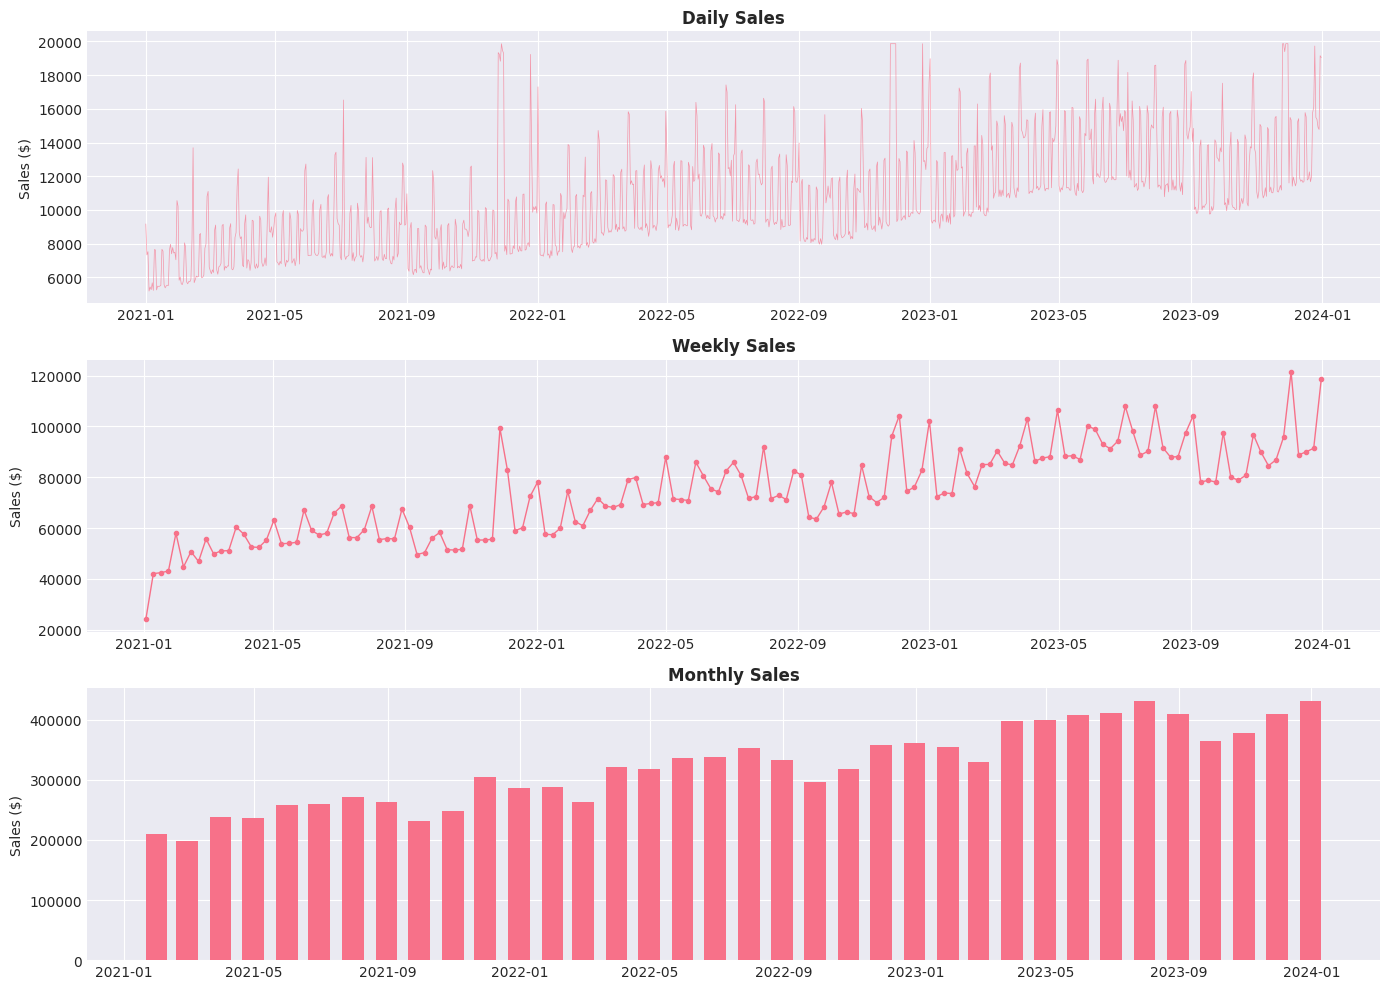

In [8]:
# CELL 7: Resample Data for Different Granularities
print("="*80)
print("RESAMPLING DATA")
print("="*80)

# Create daily, weekly, and monthly aggregations
daily_sales = df.groupby(df.index)['Sales_Amount_Capped'].sum()
weekly_sales = df.resample('W').agg({
    'Sales_Amount_Capped': 'sum',
    'Units_Sold': 'sum'
})
monthly_sales = df.resample('M').agg({
    'Sales_Amount_Capped': 'sum',
    'Units_Sold': 'sum'
})

print("Daily Sales Sample:")
print(daily_sales.head())
print(f"\nDaily Sales Stats: Mean=${daily_sales.mean():,.2f}, Std=${daily_sales.std():,.2f}")

print("\nWeekly Sales Sample:")
print(weekly_sales.head())

print("\nMonthly Sales Sample:")
print(monthly_sales.head())

# Visualize
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

axes[0].plot(daily_sales.index, daily_sales.values, linewidth=0.5, alpha=0.7)
axes[0].set_title('Daily Sales', fontweight='bold')
axes[0].set_ylabel('Sales ($)')

axes[1].plot(weekly_sales.index, weekly_sales['Sales_Amount_Capped'], marker='o', linewidth=1, markersize=3)
axes[1].set_title('Weekly Sales', fontweight='bold')
axes[1].set_ylabel('Sales ($)')

axes[2].bar(monthly_sales.index, monthly_sales['Sales_Amount_Capped'], width=20)
axes[2].set_title('Monthly Sales', fontweight='bold')
axes[2].set_ylabel('Sales ($)')

plt.tight_layout()
plt.show()

In [9]:
# CELL 8: Save Cleaned Dataset
print("="*80)
print("SAVING CLEANED DATASET")
print("="*80)

# Save the cleaned dataset
df.to_csv('data/cleaned_sales_data.csv')
print("✓ Cleaned dataset saved to 'data/cleaned_sales_data.csv'")

# Display final info
print("\n" + "="*80)
print("FINAL DATASET SUMMARY")
print("="*80)
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"Memory usage: {df.memory_usage().sum() / 1024**2:.2f} MB")

print("\n" + "="*80)
print("DATA PREPARATION COMPLETE!")
print("="*80)
print("✓ Ready for Exploratory Analysis (Notebook 2)")

SAVING CLEANED DATASET
✓ Cleaned dataset saved to 'data/cleaned_sales_data.csv'

FINAL DATASET SUMMARY
Shape: (21900, 22)
Columns: ['Year', 'Month', 'Day', 'Weekday', 'Product_Category', 'Region', 'Sales_Amount', 'Units_Sold', 'Promotion_Active', 'Holiday', 'Weekend', 'Month_End', 'Sales_Amount_Capped', 'Quarter', 'Day_Of_Year', 'Is_Weekend', 'Is_Month_End', 'Season', 'Days_Since_Start', 'Category_Encoded', 'Region_Encoded', 'Season_Encoded']
Memory usage: 2.76 MB

DATA PREPARATION COMPLETE!
✓ Ready for Exploratory Analysis (Notebook 2)
